In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

from snn import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from snn.model import IN, LIF, PSP

# Simulator backend in STACS
from snn.backend import SimSTACS

In [2]:
# General classes needed for Fibonacci
class Input(Network):
    def __init__(self, spike_times):
        super().__init__()
        self.spike_times = spike_times # n x t

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)

        return

class Adder(Network):
    def __init__(self):
        super().__init__()
        self.input = NodePort() # number of inputs generates a dependency

    def build(self):
        num_input = len(self.input)
        num_carry = 2 * num_input - 1
        self.carry = NodeGroup(LIF(), num_carry, threshold=[0.9+i for i in range(num_carry)])
        self.output = NodeGroup(LIF(threshold=0.9), 1) # default params can go in node model

        # Input to Carry
        self.ic = EdgeGroup(self.input, self.carry, PSP(),
                            list(itertools.product(range(num_input), range(num_carry))))

        # Carry to Carry
        edges = list()
        i = 1
        for c1 in range(1,num_carry,2):
            for c2 in range(c1-i,num_carry):
                edges.append((c1,c2))
            i += 1
        self.cc = EdgeGroup(self.carry, self.carry, PSP(), edges)

        # Carry to Output
        self.co = EdgeGroup(self.carry, self.output, PSP(),
                            edges=[(i,0) for i in range(num_carry)],
                            weight=[1.0 - (i%2)*2.0 for i in range(num_carry)])

        return

# Simple delay, but as a network
class TemporalShift(Network):
    def __init__(self, delay):
        super().__init__()
        self.delay = delay
        self.input = NodePort(1)

    def build(self):
        self.output = NodeGroup(LIF(threshold=0.9))
        self.i__o = EdgeGroup(self.input, self.output, PSP(), delay=self.delay)
        
        return

In [3]:
# Base case
input_f1 = [[]]  # [0, 0]
input_f2 = [[0]] # [1, 0]
shift_delay = 2 # how long it takes to go through the adder
fib_end = 20

net = Network()
# Inputs (F1, F2)
net.f1 = Input(spike_times=input_f1)
net.f2 = Input(spike_times=input_f2)

# Adder for F3
net.f3 = Adder()
net.f3_in = NodeList([net.f1.spikegen[0], net.f2.spikegen[0]])
net.connect(net.f3_in, net.f3.input)

# Temporal Shift from F2
net.s2 = TemporalShift(shift_delay)
net.connect(net.f2.spikegen, net.s2.input)

# Adder for F4
net.f4 = Adder()
net.f4_in = NodeList([net.s2.output[0], net.f3.output[0]])
net.connect(net.f4_in, net.f4.input)

# Automate the building of the next several adders
for i in range(5, fib_end):
    setattr(net, f"s{i-2}", TemporalShift(shift_delay))
    # Might be nice to have convenience functions for this..
    net.connect(getattr(net, f"f{i-2}").output, getattr(net, f"s{i-2}").input)

    setattr(net, f"f{i}", Adder())
    setattr(net, f"f{i}_in", NodeList([getattr(net, f"s{i-2}").output[0],
                                       getattr(net, f"f{i-1}").output[0]]))
    net.connect(getattr(net, f"f{i}_in"), getattr(net, f"f{i}").input)

# Manual build of the next several adders
# # Temporal Shift from F3
# net.s3 = TemporalShift(shift_delay)
# net.connect(net.f3.output, net.s3.input)

# # Adder for F5
# net.f5 = Adder()
# net.f5_in = NodeList([net.s3.output[0], net.f4.output[0]])
# net.connect(net.f5_in, net.f5.input)

info: adding network f1
info: adding network f2
info: adding network f3
info: adding network s2
info: adding network f4
info: adding network s3
info: adding network f5
info: adding network s4
info: adding network f6
info: adding network s5
info: adding network f7
info: adding network s6
info: adding network f8
info: adding network s7
info: adding network f9
info: adding network s8
info: adding network f10
info: adding network s9
info: adding network f11
info: adding network s10
info: adding network f12
info: adding network s11
info: adding network f13
info: adding network s12
info: adding network f14
info: adding network s13
info: adding network f15
info: adding network s14
info: adding network f16
info: adding network s15
info: adding network f17
info: adding network s16
info: adding network f18
info: adding network s17
info: adding network f19


In [4]:
net.build()

info: building network f1
info: building network f2
info: building network s2
info: building network s3
info: building network s4
info: building network s5
info: building network s6
info: building network s7
info: building network s8
info: building network s9
info: building network s10
info: building network s11
info: building network s12
info: building network s13
info: building network s14
info: building network s15
info: building network s16
info: building network s17
info: linking port f3.input
info: linking port s2.input
info: linking port f4.input
info: waiting on source f3.output
info: linking port f5.input
info: waiting on source f4.output
info: linking port f6.input
info: waiting on source f5.output
info: linking port f7.input
info: waiting on source f6.output
info: linking port f8.input
info: waiting on source f7.output
info: linking port f9.input
info: waiting on source f8.output
info: linking port f10.input
info: waiting on source f9.output
info: linking port f11.input
info

/Users/felwang/Documents/Projects/STACS/stacs/charmrun +p1 /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml

Running as 1 OS processes:  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
charmrun> mpirun -np 1  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
Charm++> Running on MPI version: 4.1
Charm++> level of thread support used: -1 (desired: 0)
Charm++> Running in non-SMP mode: 1 processes (PEs)
Converse/Charm++ Commit ID: v70000
Charm++ built without optimization.
Do not use for performance benchmarking (build with --with-production to do so).
Charm++ built with internal error checking enabled.
Do not use for performance benchmarking (build without --enable-error-checking to do so).
CharmLB> Load balancer assumes all CPUs are same.
Charm++> Running on 1 hosts (1 sockets x 12 cores x 1 PUs = 12-way SMP)
Charm++> cpu topology info is gathered in 0.003 seconds.

Simulation Tool for Asynchronous Cortical Streams

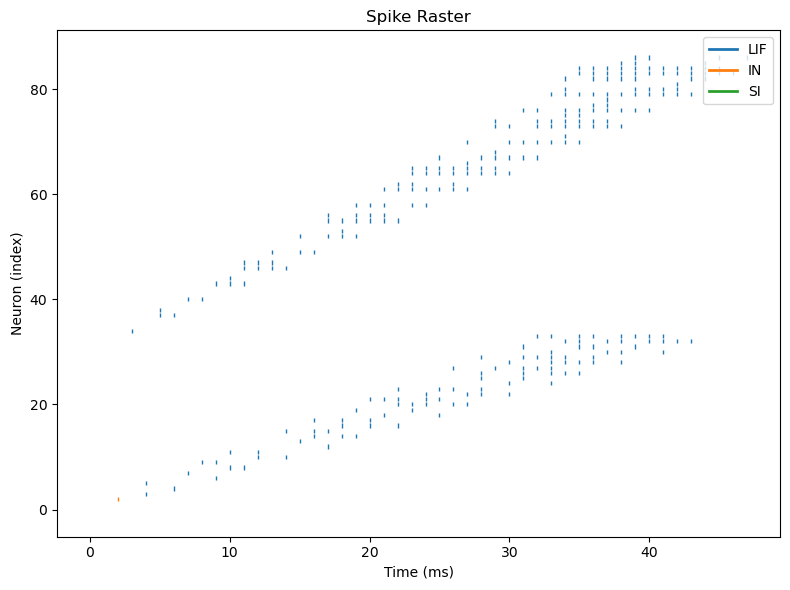

In [5]:
# Simulate it in STACS
sim = SimSTACS(net)
sim.compile()
sim.run(50, verbose=True)
sim.plot_spikes()

In [6]:
spike_list = sim.get_spikes()

# Compute fibonacci values
for i in range(0,fib_end-3):
    # Timestamp for adder output begin
    t0 = 4 + 2*i # 2 timesteps per adder
    # Get the neuron number for the adder outputs
    index = sim.node_map[getattr(net, f"f{i+3}").output[0].name]
    # Get value from timestamps
    num = 0
    for t in spike_list[index]:
        timestep = int(t - t0)
        num += 2**(timestep)
    # Print out information
    print(f"Fibonacci for {i+2}: {num} (at neuron {index})")

Fibonacci for 2: 1 (at neuron 5)
Fibonacci for 3: 2 (at neuron 7)
Fibonacci for 4: 3 (at neuron 9)
Fibonacci for 5: 5 (at neuron 11)
Fibonacci for 6: 8 (at neuron 13)
Fibonacci for 7: 13 (at neuron 15)
Fibonacci for 8: 21 (at neuron 17)
Fibonacci for 9: 34 (at neuron 19)
Fibonacci for 10: 55 (at neuron 21)
Fibonacci for 11: 89 (at neuron 23)
Fibonacci for 12: 144 (at neuron 25)
Fibonacci for 13: 233 (at neuron 27)
Fibonacci for 14: 377 (at neuron 29)
Fibonacci for 15: 610 (at neuron 31)
Fibonacci for 16: 987 (at neuron 33)
Fibonacci for 17: 1597 (at neuron 82)
Fibonacci for 18: 2584 (at neuron 86)


In [7]:
# Recursive version (feeding the output of adder back into itself)
input_f1 = [[]]  # [0, 0]
input_f2 = [[0]] # [1, 0]
precision = 148 # Need enough precision (timesteps) to 
shift_delay = 2
fib_end = 200

net = Network()
# Inputs (F1, F2)
net.f1 = Input(spike_times=input_f1)
net.f2 = Input(spike_times=input_f2)

# Relay neuron to get input from spikegen (or recurrently)
net.relay = NodeGroup(LIF(threshold=0.9), 2)
net.connect(net.f1.spikegen, net.relay, PSP(), edges=[(0,0)])
net.connect(net.f2.spikegen, net.relay, PSP(), edges=[(0,1)])

# Main adder
net.f = Adder()
net.connect(net.relay, net.f.input)

# Temporal Shift from Adder
net.s1 = TemporalShift(precision - shift_delay - 1)
net.s2 = TemporalShift(2*precision - shift_delay - 1)

# Connect adder output to temporal shift
net.connect(net.f.output, net.s1.input)
net.connect(net.f.output, net.s2.input)

# And also from the spikegen
net.connect(net.f2.spikegen, net.relay, PSP(delay=precision+shift_delay-1), edges=([(0,1)]))

# Connect shift to relay
net.connect(net.s1.output, net.relay, PSP(), edges=([(0,0)]))
net.connect(net.s2.output, net.relay, PSP(), edges=([(0,1)]))

info: adding network f1
info: adding network f2
info: adding network f
info: adding network s1
info: adding network s2


In [8]:
net.build()

info: building network f1
info: building network f2
info: building network s1
info: building network s2
info: adding unnamed edgegroup
info: adding unnamed edgegroup
info: linking port f.input
info: waiting on source f.output
info: waiting on source f.output
info: adding unnamed edgegroup
info: adding unnamed edgegroup
info: adding unnamed edgegroup
info: resolving dependency for f.input
info: building network f
info: linking port s1.input
info: linking port s2.input
info: flattening network topology


In [9]:
print(net)

(edge) edgegroups[0]: (node) f1.spikegen -> (node) relay
(edge) edgegroups[1]: (node) f2.spikegen -> (node) relay
(edge) edgegroups[2]: (node) f2.spikegen -> (node) relay
(edge) edgegroups[3]: (node) s1.output -> (node) relay
(edge) edgegroups[4]: (node) s2.output -> (node) relay
(node) relay
(node) f1.spikegen
(node) f2.spikegen
(port) s1.input <- (node) f.output
(node) s1.output
(edge) s1.i__o: (port) s1.input <- (node) f.output -> (node) s1.output
(port) s2.input <- (node) f.output
(node) s2.output
(edge) s2.i__o: (port) s2.input <- (node) f.output -> (node) s2.output
(port) f.input <- (node) relay
(node) f.carry
(node) f.output
(edge) f.ic: (port) f.input <- (node) relay -> (node) f.carry
(edge) f.cc: (node) f.carry -> (node) f.carry
(edge) f.co: (node) f.carry -> (node) f.output


/Users/felwang/Documents/Projects/STACS/stacs/charmrun +p1 /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml

Running as 1 OS processes:  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
charmrun> mpirun -np 1  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
Charm++> Running on MPI version: 4.1
Charm++> level of thread support used: -1 (desired: 0)
Charm++> Running in non-SMP mode: 1 processes (PEs)
Converse/Charm++ Commit ID: v70000
Charm++ built without optimization.
Do not use for performance benchmarking (build with --with-production to do so).
Charm++ built with internal error checking enabled.
Do not use for performance benchmarking (build without --enable-error-checking to do so).
CharmLB> Load balancer assumes all CPUs are same.
Charm++> Running on 1 hosts (1 sockets x 12 cores x 1 PUs = 12-way SMP)
Charm++> cpu topology info is gathered in 0.003 seconds.

Simulation Tool for Asynchronous Cortical Streams

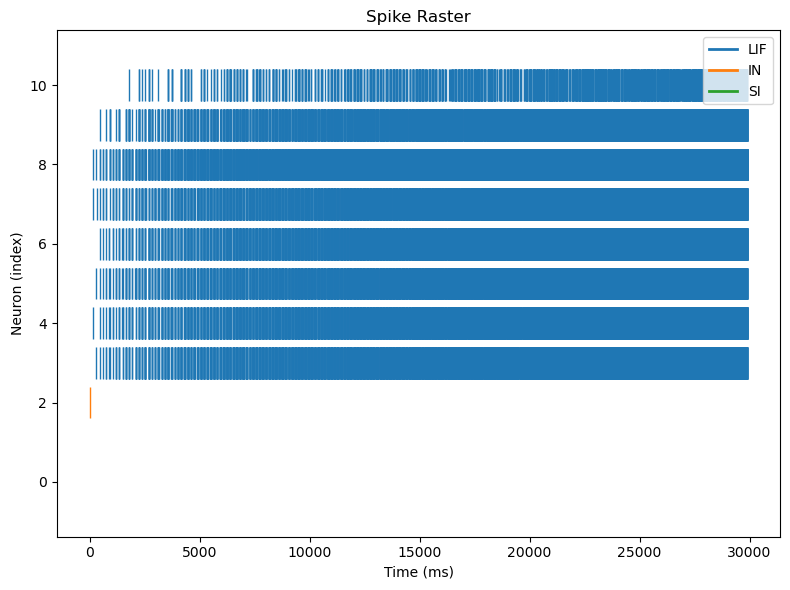

In [10]:
# Simulate it in STACS
sim = SimSTACS(net)
sim.compile()
sim.run((fib_end+2)*precision, verbose=True)
sim.plot_spikes()

In [11]:
spike_list = sim.get_spikes()

index = sim.node_map[net.f.output[0].name]
output_array = np.asarray(spike_list[index], dtype=int)

# Compute fibonacci values
for i in range(0,fib_end):
    # Timestamp for adder output begin and end
    t0 = 5 + precision*(i+2) # precision timesteps per adder
    t1 = 5 + precision*(i+3)
    idx = np.where((output_array >= t0) & (output_array < t1))
    # Get value from timestamps
    num = 0
    for t in output_array[idx]:
        timestep = int(t - t0)
        num += 2**(timestep)
    # Print out information
    print(f"Fibonacci for {i+2}: {num}")

Fibonacci for 2: 1
Fibonacci for 3: 2
Fibonacci for 4: 3
Fibonacci for 5: 5
Fibonacci for 6: 8
Fibonacci for 7: 13
Fibonacci for 8: 21
Fibonacci for 9: 34
Fibonacci for 10: 55
Fibonacci for 11: 89
Fibonacci for 12: 144
Fibonacci for 13: 233
Fibonacci for 14: 377
Fibonacci for 15: 610
Fibonacci for 16: 987
Fibonacci for 17: 1597
Fibonacci for 18: 2584
Fibonacci for 19: 4181
Fibonacci for 20: 6765
Fibonacci for 21: 10946
Fibonacci for 22: 17711
Fibonacci for 23: 28657
Fibonacci for 24: 46368
Fibonacci for 25: 75025
Fibonacci for 26: 121393
Fibonacci for 27: 196418
Fibonacci for 28: 317811
Fibonacci for 29: 514229
Fibonacci for 30: 832040
Fibonacci for 31: 1346269
Fibonacci for 32: 2178309
Fibonacci for 33: 3524578
Fibonacci for 34: 5702887
Fibonacci for 35: 9227465
Fibonacci for 36: 14930352
Fibonacci for 37: 24157817
Fibonacci for 38: 39088169
Fibonacci for 39: 63245986
Fibonacci for 40: 102334155
Fibonacci for 41: 165580141
Fibonacci for 42: 267914296
Fibonacci for 43: 433494437
Fibona